# Example: Linear Regression

Sam Foreman [](https://orcid.org/0000-0002-9981-0876)
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/sam-foreman>))  
Huihuo Zheng
(\[[ANL](https://www.anl.gov/)\](<https://alcf.anl.gov/about/people/huihuo-zheng>))  
2025-07-15

[](https://colab.research.google.com/github/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/6-linear-regression/index.ipynb)
[](https://github.com/saforem2/intro-hpc-bootcamp/blob/main/docs/00-intro-AI-HPC/6-linear-regression/README.md)

In this notebook, we will talk about:

- What is AI training?
- How does large language model work?
- A simple AI model: linear regression

ALCF Specific Setup

## How to run this notebook on Polaris

- Go to <https://jupyter.alcf.anl.gov>, and click “Login Polaris”
- After login, select `ALCFAITP` project and `ALCFAITP` queue during the
  lecture (use `debug` queue outside of the lecture)
- Load the notebook and select “datascience/conda-2023-01-10” python
  kernel

<figure id="fig-jupyter">
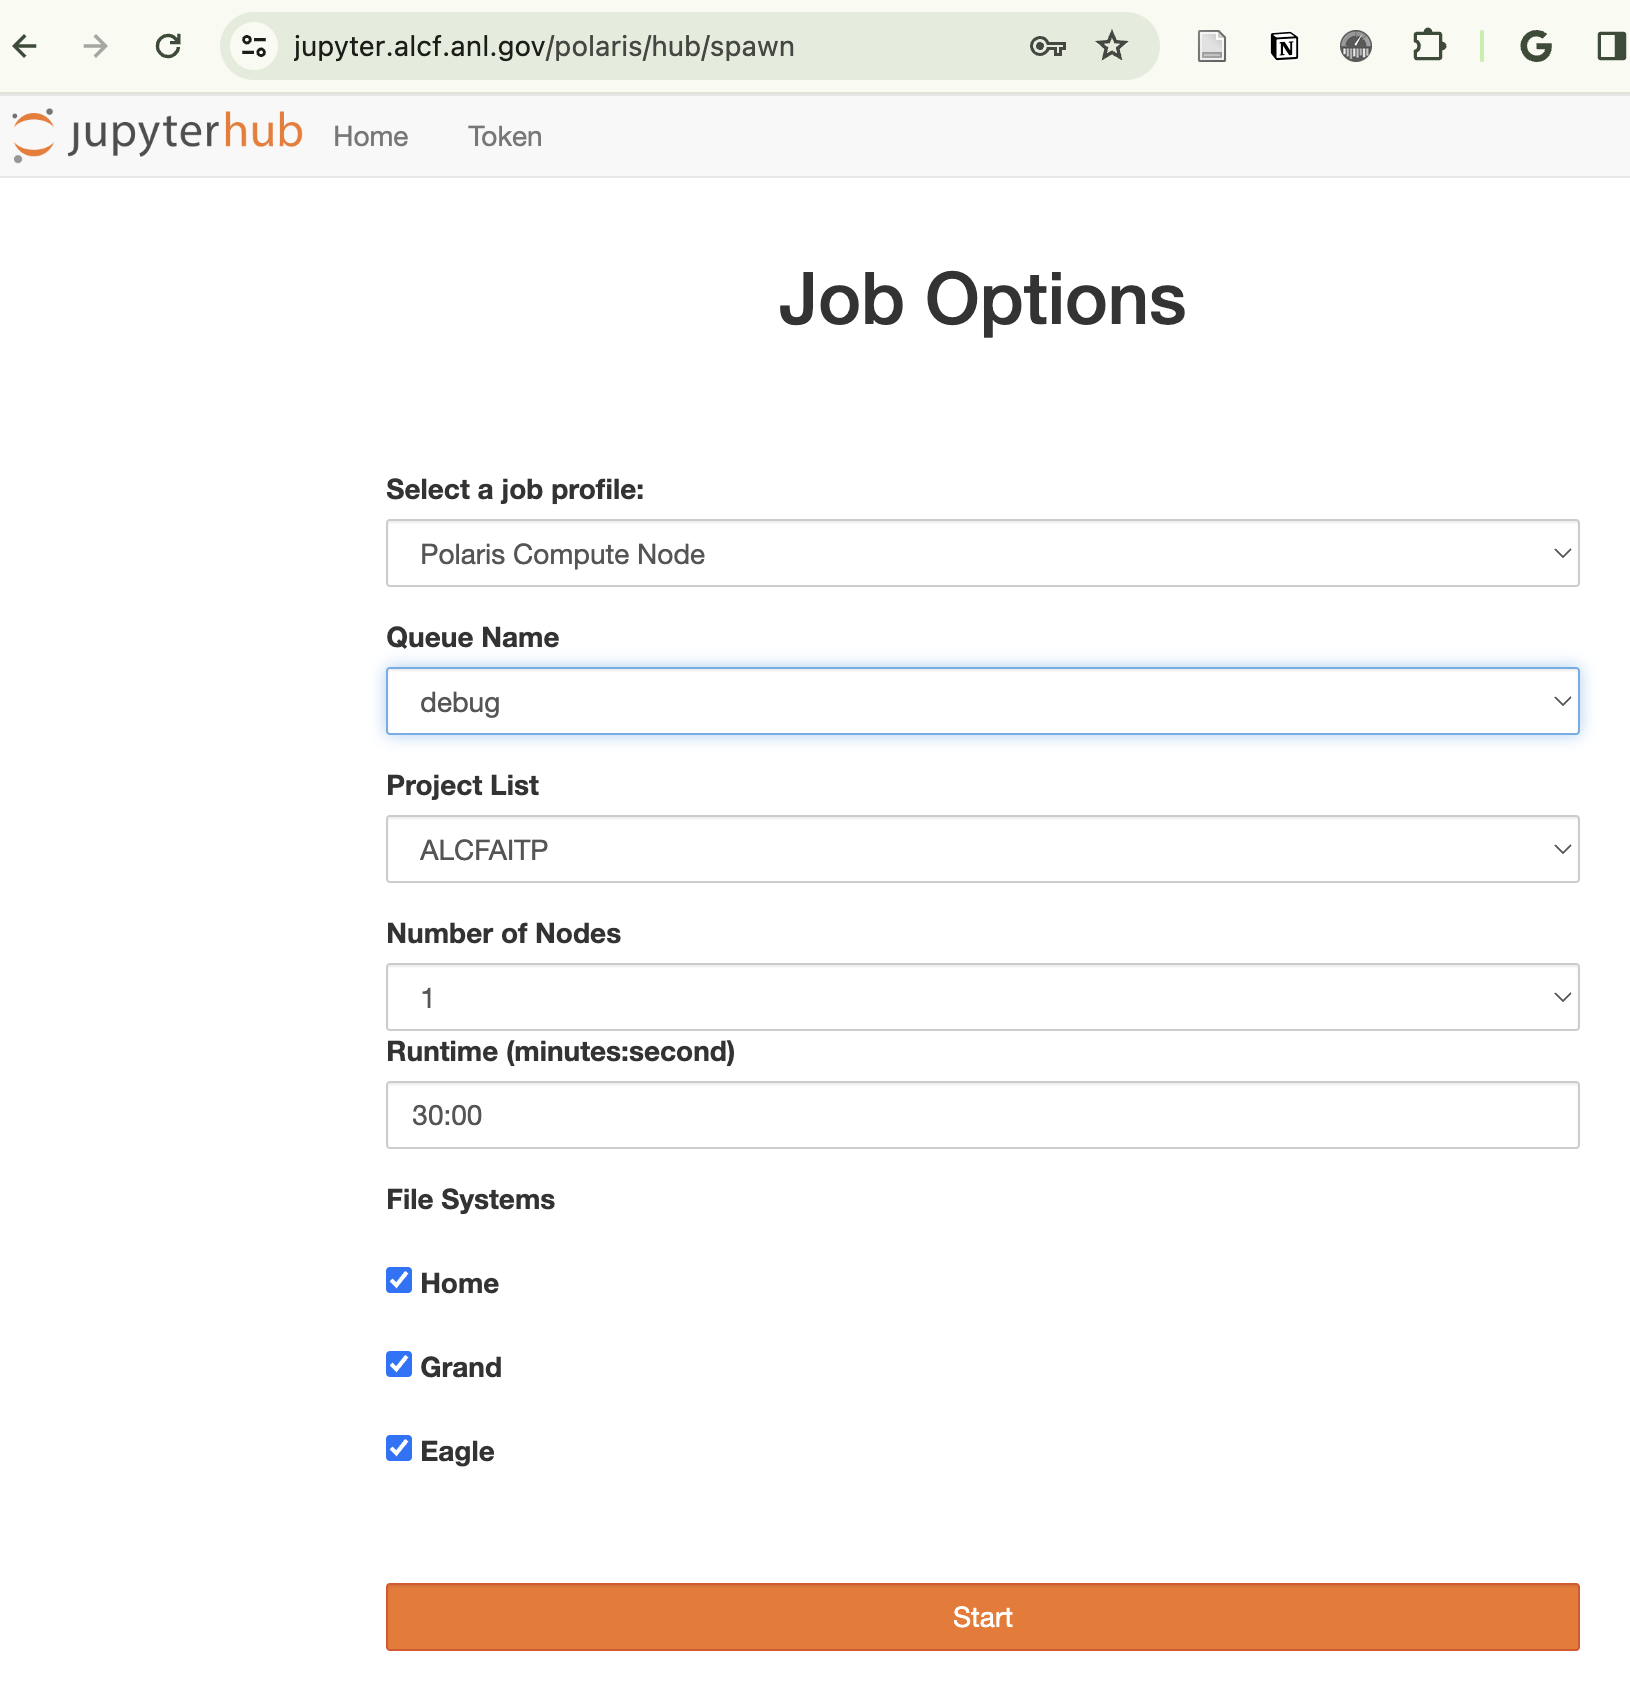
<figcaption>Figure 1</figcaption>
</figure>

**How to run this notebook on Google Colab**

- Go to https://colab.research.google.com/, sign in or sign up

- “File”-\> “open notebook”

- Choose `01_intro_AI_on_Supercomputer/01_linear_regression_sgd.ipynb`
  from the list

  <figure>
  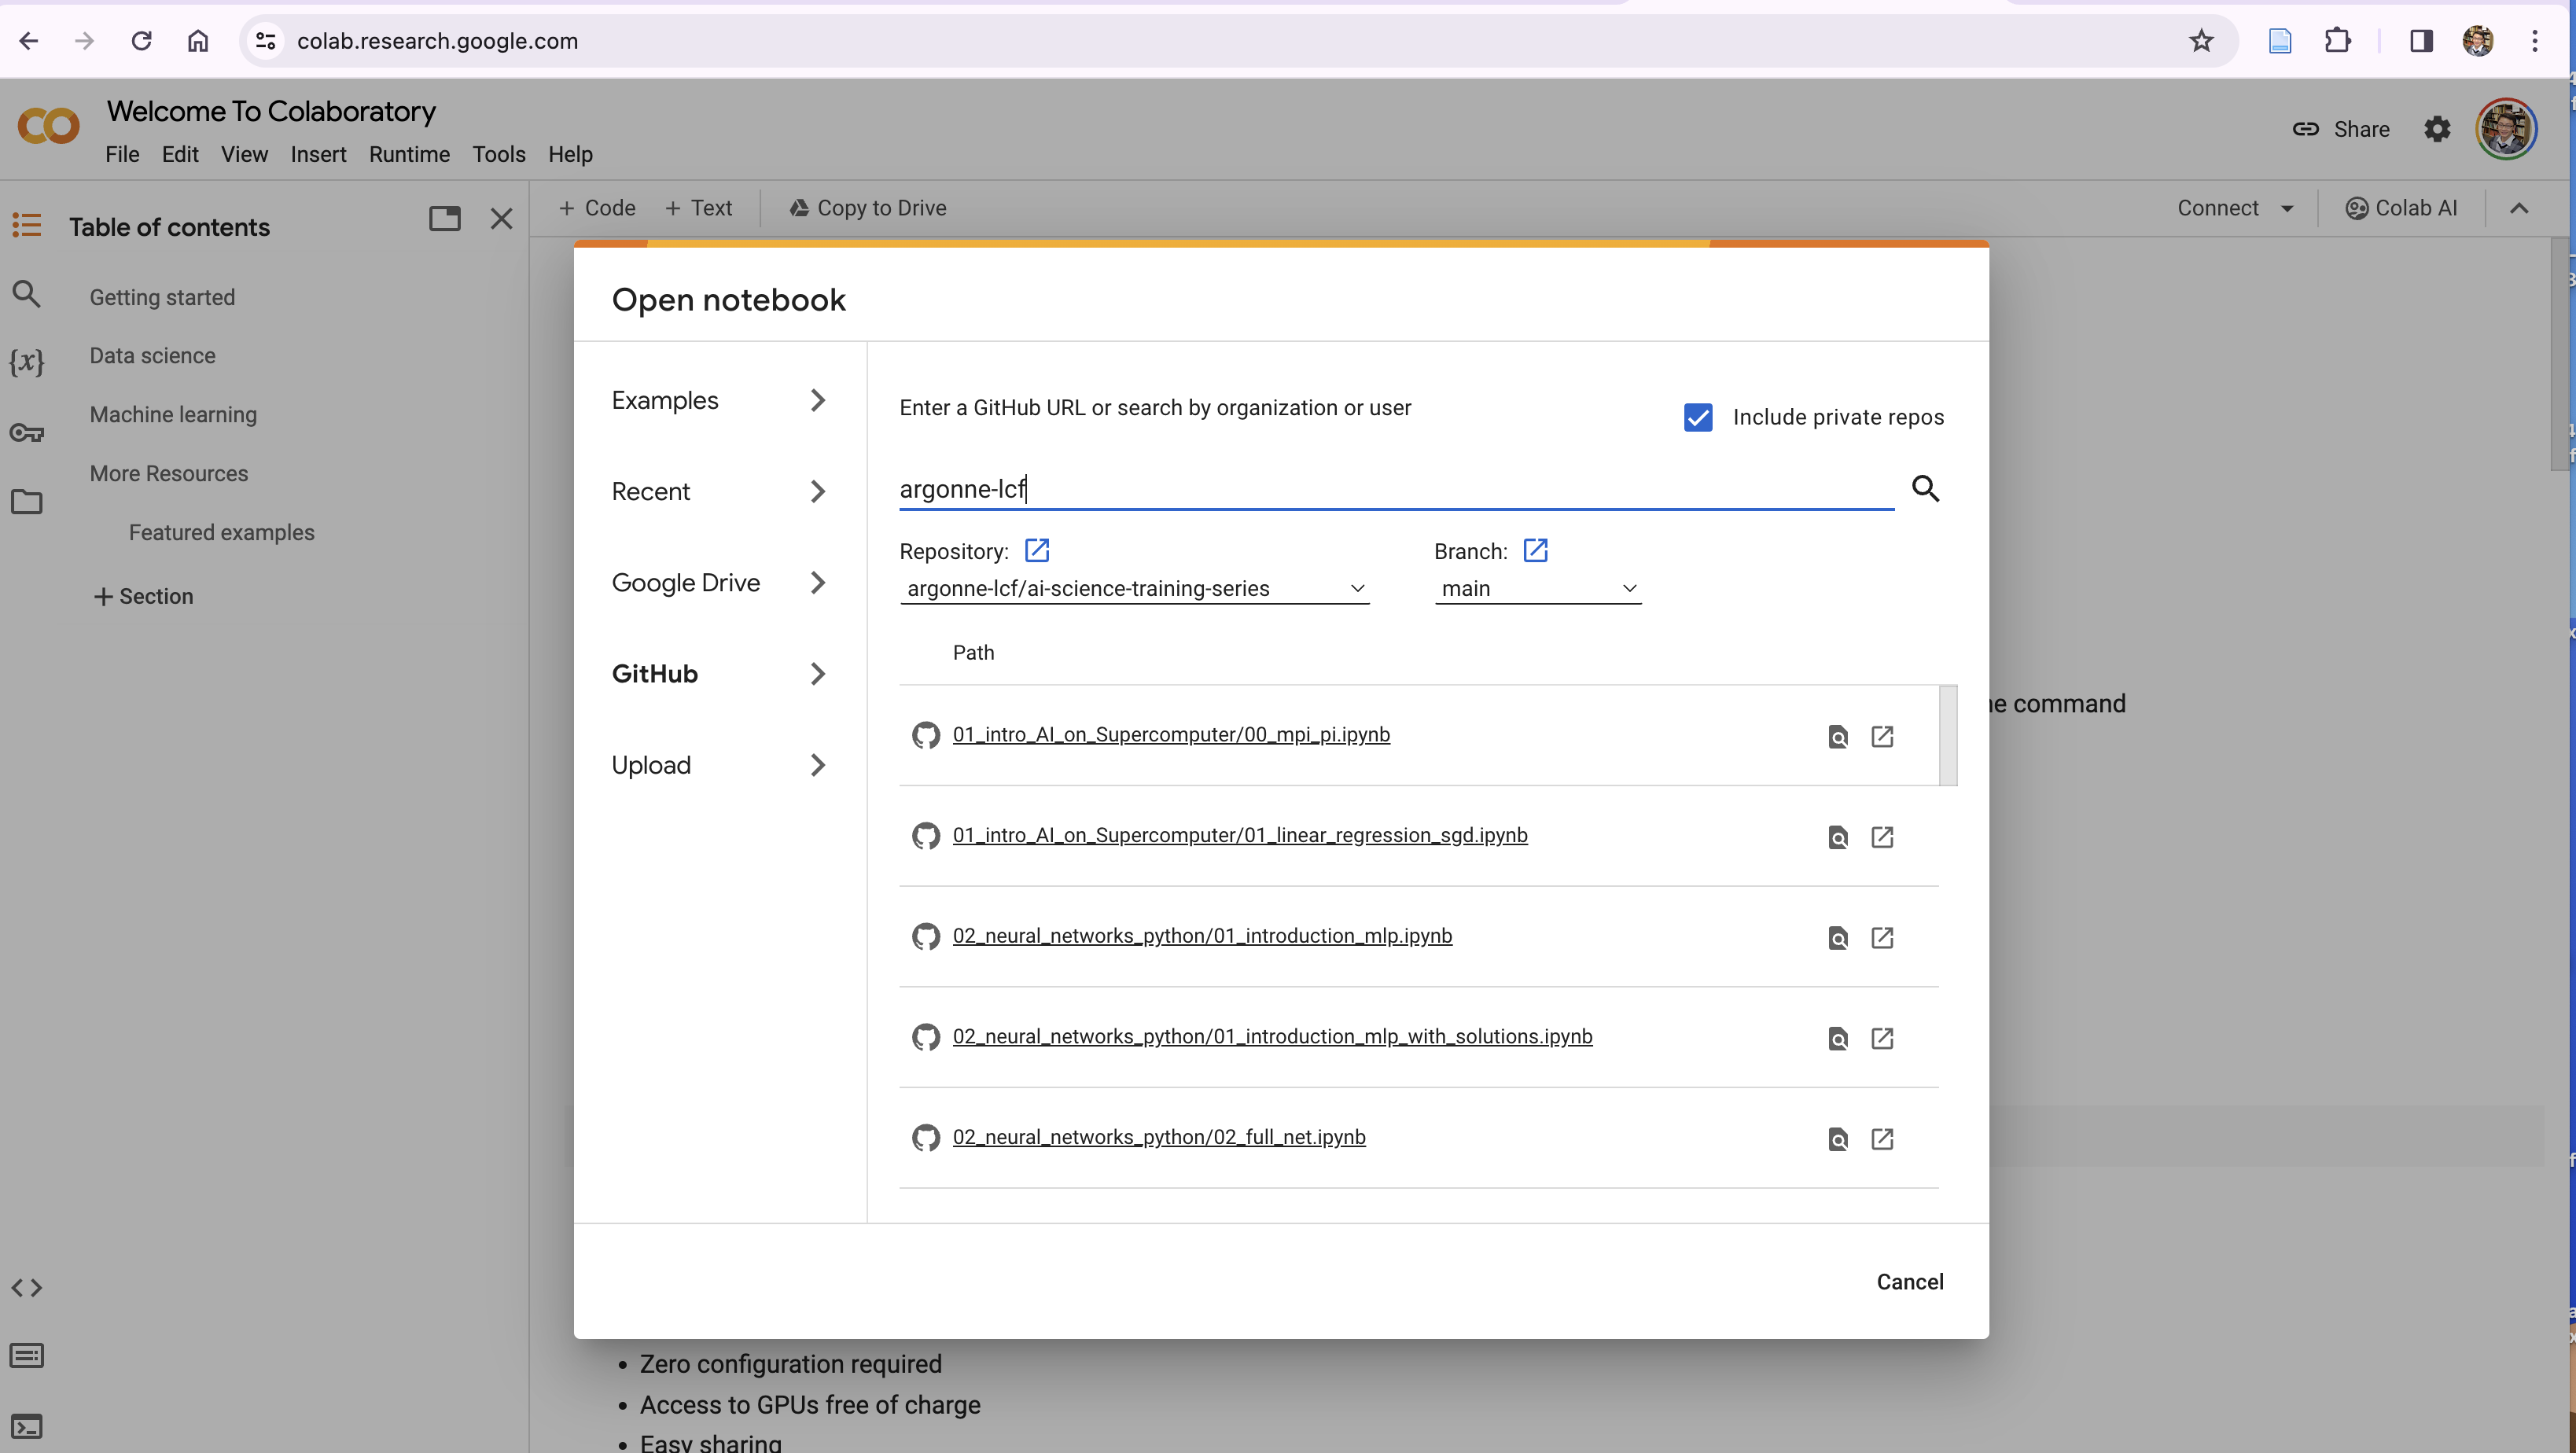
  <figcaption aria-hidden="true">Google Colab</figcaption>
  </figure>

## What is AI training?

There are two very different ways to learn a skill like speaking a
language:

- **learning the rules** — memorize grammar, then apply it (traditional
  programming), or
- **learning from examples** — hear enough speech that the patterns sink
  in (data-driven learning).

The second is the essence of AI: rather than being handed the rules, the
model **infers** them from many examples. Given enough data,
pattern-learning is remarkably powerful — it’s how modern AI, from image
classifiers to large language models, works.

## How does a large language model work?

Large language models like GPT learn this way at massive scale:
**pre-train** on enormous text corpora to absorb language patterns, use
the **transformer** architecture to weigh context, and optionally
**fine-tune** for specific tasks — so they can generate coherent,
contextually relevant text from a prompt.

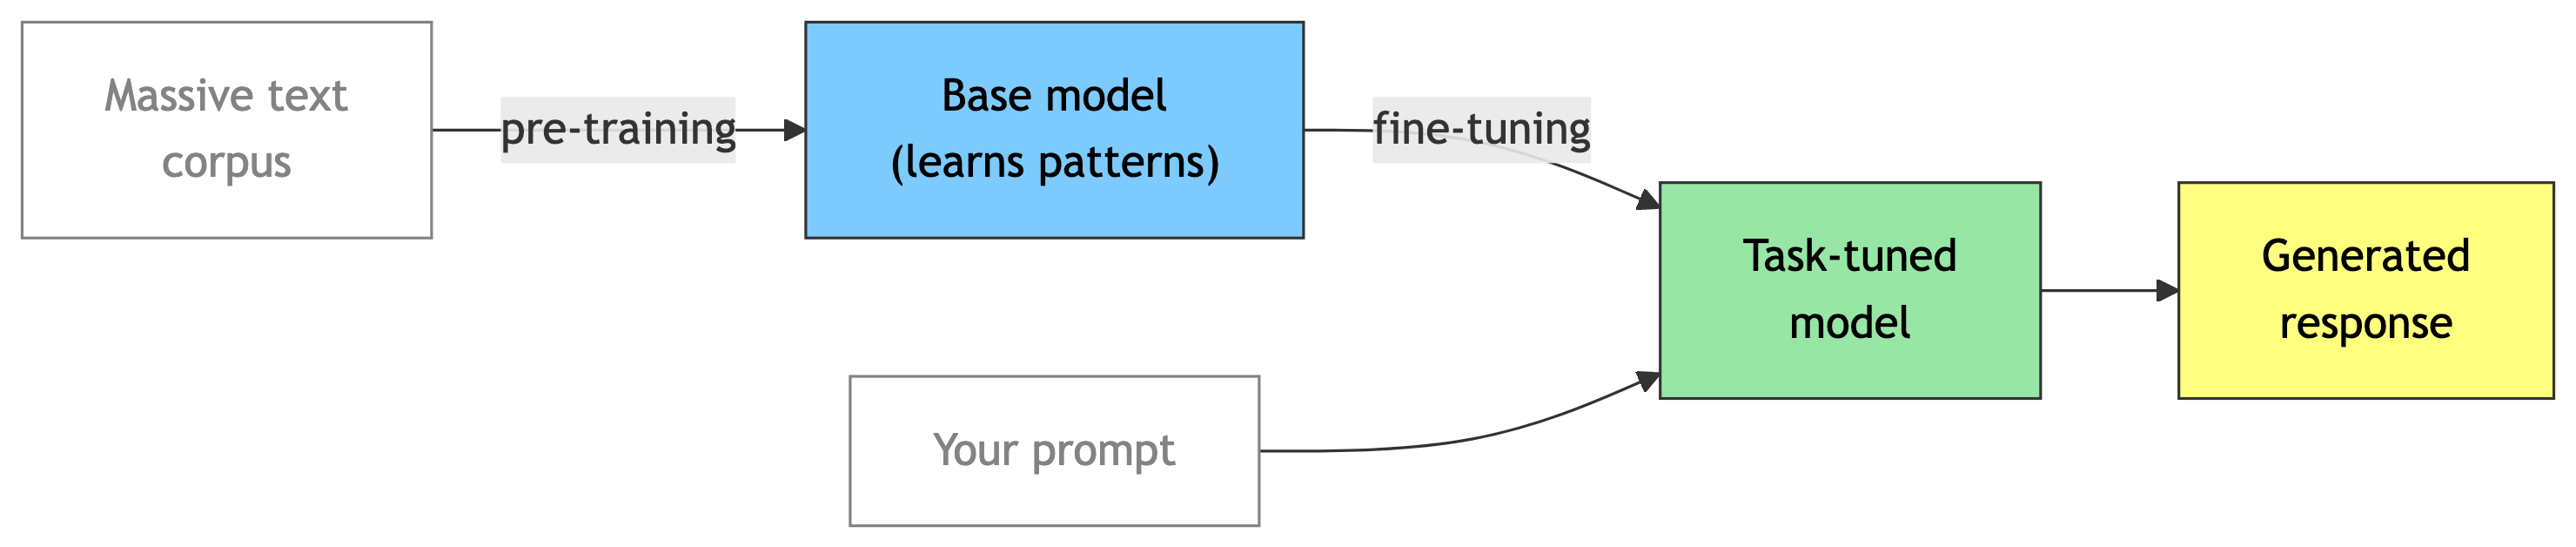

The huge models are exciting, but the *core idea* — fit a function to
data so it can predict on new inputs — is easiest to see in the simplest
possible model.

## Simplest AI model example: linear regression

This example is adapted from Bethany Lusch, ALCF.

Linear regression is the simplest example of learning from existing data
to make future predictions: we fit a straight line $y = mx + b$ through
a cloud of points so we can predict $y$ for a new $x$. Everything else
in this course — neural networks, LLMs — is a more elaborate version of
this same idea.

We’re going to review the math involved in this process to help
understand how training an AI works.

First we will load some tools that others wrote and we can use to help
us work.

- [Pandas](https://pandas.pydata.org/docs/): a toolkit for working with
  row vs. column data, like excel sheets, and CSV (Comma Seperated
  Values) files.
- [Numpy](https://numpy.org/doc/): a toolkit for managing arrays,
  vectors, matrices, etc, doing math with them, slicing them up, and
  many other handy things.
- [Matplotlib](https://matplotlib.org/stable/index.html): a toolkit for
  plotting data

In [1]:
# This page uses the `bootcamp` helper package. On Colab (or any fresh
# environment) install it + its dependencies; locally this is a no-op.
try:
    import bootcamp  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/saforem2/intro-hpc-bootcamp"

In [2]:
import os
os.environ["FORCE_COLOR"] = "1"
os.environ["TTY_INTERACTIVE"] = "1"
import ambivalent

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use(ambivalent.STYLES['ambivalent'])
sns.set_context("notebook")
plt.rcParams["figure.figsize"] = [6.4, 4.8]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipydis
import time

import plotly.graph_objects as go   # interactive charts
from bootcamp.plotly_theme import apply_theme, COLORS
apply_theme()   # house style + self-contained (inlines plotly.js, no CDN)

from rich import print

### Dataset

We used a realestate dataset from Kaggle to produce this reduced
dataset.

This dataset contains the *sale price* and *above ground square feet* of
many houses. We can use this data for our linear regression.

We use Pandas to read the data file which is stored as Comma Separated
Values (CSV) and print the column labels.

CSV files are similar to excel sheets.

In [3]:
! [ -e ./slimmed_realestate_data.csv ] || wget https://raw.githubusercontent.com/argonne-lcf/ai-science-training-series/main/01_intro_AI_on_Supercomputer/slimmed_realestate_data.csv
data = pd.read_csv('slimmed_realestate_data.csv')
print(data.columns)

Index ([ 'Unnamed: 0' , 'SalePrice' , 'GrLivArea' ] , dtype = 'object' )

Let’s inspect our data with an **interactive scatter plot** — hover over
any point to see its exact square footage and sale price, and drag to
zoom:

In [4]:
fig = go.Figure()
fig.add_scatter(
    x=data["GrLivArea"], y=data["SalePrice"],
    mode="markers",
    marker=dict(size=6, color=COLORS["blue"], opacity=0.7),
    hovertemplate="%{x:,.0f} sq ft<br>$%{y:,.0f}<extra></extra>",
    name="homes",
)
fig.update_layout(
    xaxis_title="Above-ground living area (sq ft)",
    yaxis_title="Sale price ($)",
    height=420,
)
fig.show()

> **🖱️ It’s interactive**
>
> These are [Plotly](https://plotly.com/python/) charts, not static
> images — **hover** to read values, **drag** to zoom, **double-click**
> to reset, and use the toolbar (top-right) to pan or download a PNG.

### Theory of linear regression

The goal of learning regression is to find a line that is closest to all
the points.

The slope and intercept of such a line $y = m x + b$ can be found as:

$$m = { n (\Sigma xy) - (\Sigma x) (\Sigma y) \over n (\Sigma x^2) - (\Sigma x)^2 } $$

$$b = { (\Sigma y) (\Sigma x^2) - (\Sigma x) (\Sigma xy) \over n (\Sigma x^2) - (\Sigma x)^2 } $$

Details derivation of this can be found
[here](https://en.wikipedia.org/wiki/Simple_linear_regression).

We’ll break this calculation into a few steps to help make it easier.

First lets define $x$ and $y$. $x$ will be our *above ground square
footage* and $y$ will be *sale price*. In our equations we have a few
different values we need, such as $n$ which is just the number of points
we have:

In [5]:
n = len(data)

Then we need our $x$ and $y$ by selecting only the column we care about
for each one. Note about data formats: `data` is a Pandas
[DataFrame](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame)
object which has rows and columns; `data['GrLivArea']` is a Pandas
[Series](https://pandas.pydata.org/docs/reference/api/pandas.Series.html)
object which only has rows; then we also convert from *Pandas* data
formats (in this case a *Series*) to *Numpy* data formats using the
`to_numpy()` function which is part of the Pandas *Series* object.

In [6]:
x = data['GrLivArea'].to_numpy()
y = data['SalePrice'].to_numpy()

Now we will calculate $\Sigma xy$, $\Sigma x$, $\Sigma y$, and
$\Sigma x^2$:

In [7]:
sum_xy = np.sum(x*y)
sum_x = np.sum(x)
sum_y = np.sum(y)
sum_x2 = np.sum(x*x)

The denominator in the equation for $m$ and $b$ are the same so we can
calculate that once:

In [8]:
denominator = n * sum_x2 - sum_x * sum_x

Then we can calculate our fit values:

In [9]:
m = (n * sum_xy - sum_x * sum_y) / denominator
b = (sum_y * sum_x2 - sum_x * sum_xy) / denominator
print('y = %f * x + %f' % (m,b))

# saving these for later comparison
m_calc = m
b_calc = b

y = 87.688145 * x + 34754.077892

Now we can plot the fit results with our data to see how we did.

First we define a plotting function because we’re going to do this often
and we want to reuse our code:

In [10]:
def plot_data(x, y, m, b, fig=None):
    """Scatter the data points and overlay the fitted line y = m*x + b (interactive)."""
    if fig is None:
        fig = go.Figure()
    # our data points
    fig.add_scatter(
        x=x, y=y, mode="markers", name="data",
        marker=dict(size=6, color=COLORS["blue"], opacity=0.7),
        hovertemplate="%{x:,.0f} sq ft<br>$%{y:,.0f}<extra></extra>",
    )
    # the fitted line, evaluated across the x-range
    linear_x = np.arange(x.min(), x.max())
    linear_y = linear_x * m + b
    fig.add_scatter(
        x=linear_x, y=linear_y, mode="lines", name="fit",
        line=dict(color=COLORS["red"], width=3),
    )
    fig.update_layout(
        xaxis_title="square footage", yaxis_title="sale price", height=420,
    )
    return fig

Now we can use this function to plot our results:

In [11]:
plot_data(x, y, m, b).show()

### Training through Stochastic Gradient Descent (SGD)

SGD is a common method in AI for training deep neural networks on large
datasets. It is an iterative method for optimizing a loss function that
we get to define. The “stochastic” part is what sets it apart from plain
gradient descent: **each step uses a random mini-batch of the data
instead of the full dataset**, which is what makes it practical when the
dataset is far too large to process all at once. We will use this simple
linear regression to demonstrate how it works.

#### The model

In AI, neural networks are often referred to as a *model* because, once
fully trained, they should model (AKA predict) the behavior of our
system. In our example, the system is how house prices vary based on
house size. We know our system is roughly driven by a linear function:

$$\hat{y_i}(x_i) = m * x_i + b $$

We just need to figure out $m$ and $b$. Let’s create a function that
calculates our model given $x$, $m$, and $b$.

In [12]:
def model(x,m,b):
   return m * x + b

#### The Loss Function

A *loss function*, or *objective function*, is something we define and
is based on what we want to achieve. In the method of SGD, it is our
goal to minimize (or make close to zero) the values calculated from the
*loss function*. In our example, we ideally want the prediction of our
*model* to be equal to the actual data, though we will settle for “as
close as possible”.

So we will select our *loss function* to be the [Mean Squared
Error](https://en.wikipedia.org/wiki/Mean_squared_error) function:

$$ L(y_i,\hat{y_i}) = (y_i - \hat{y_i}(x_i))^2 $$

where $y_i$ is our $i^{th}$ entry in the `data['SalePrice']` vector and
$\hat{y_i}$ is the prediction based on evaluting $m * x_i + b$.

This function looks like the figure below when we plot it with
$x=y_i - \hat{y_i}(x_i)$ and we we want to be down near
$y_i - \hat{y_i}(x_i) = 0$ which indicates that our $y_i$ is as close as
possible to $\hat{y_i}$.

<figure id="fig-loss-func">
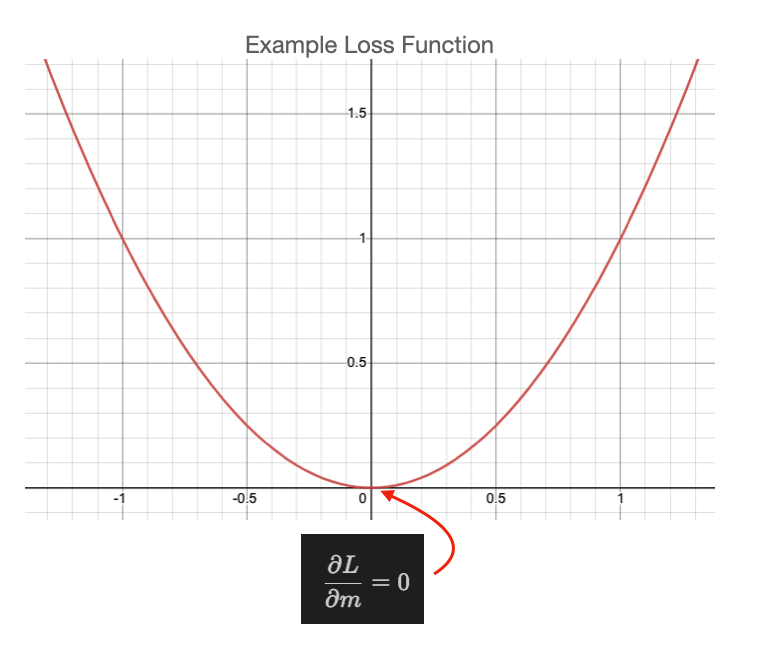
<figcaption>Figure 2: Loss function for linear regression</figcaption>
</figure>

Here we crate a function that calculates this for us.

In [13]:
def loss(x,y,m,b):
   y_predicted = model(x,m,b)
   return np.power( y - y_predicted, 2 )

#### Minimizing the Loss Function

We want to use the loss function in order to guide how to update $m$ and
$b$ to better model our system. In calculus we learn to minimize a
function with respect to a variable you calculate the *partial
derivative* with respect to the variable you want to vary.

$$ { \partial L \over \partial m } = 0 $$

The location of the solution to this is the minimum as shown in the
figure above. We can write down the partial derivative of the loss
function as:

$$ { \partial L \over \partial m } = -2 x_i (y_i - \hat{y_i}(x_i)) $$
$$ { \partial L \over \partial b } = -2 (y_i - \hat{y_i}(x_i)) $$

We can use this to calculate an adjustment to $m$ and $b$ that will
reduce the loss function, effectively improving our fitting parameters.
This is done using this equation:

$$ m' = m - \eta { \partial L \over \partial m }$$
$$ b' = b - \eta { \partial L \over \partial b }$$

Here our original $m$ and $b$ are adjusted by the partial derivative
multiplied by some small factor, $\eta$, called the *learning rate*.
This learning rate is very important in our process and must be tuned
for every problem.

In our example, the selection of the learning rate essentially defines
how close we can get to the minimum, AKA the best fit solution. We first
select a starting point in our loss function (typically randomly), then
every update from $m$/$b$ to $m'$/$b'$ shifts us to somewhere else on
the loss curve. If the learning rate ($\eta$) is too large, each step
overshoots and we bounce back and forth around the minimum, never
reaching it; if it’s too small, we crawl toward it agonizingly slowly.
The interactive demos just below let you **see this trade-off in
action** — watch the descent path change as we vary $\eta$.

Rather than describe this in the abstract, let’s **actually run gradient
descent** on a loss curve and plot the path it takes. This helper does
one thing: start at a point, repeatedly step *downhill* by
`-lr · gradient`, and record every step.

In [14]:
def gradient_descent(grad, x0, lr, steps=12, lr_decay=1.0):
    """Run GD on a 1-D loss; return the visited x positions.
    lr_decay<1 shrinks the step each iteration (a simple LR schedule)."""
    xs, x, eta = [x0], x0, lr
    for _ in range(steps):
        x = x - eta * grad(x)
        eta *= lr_decay
        xs.append(x)
    return np.array(xs)

def descent_figure(f, grad, x0, lr, xr, steps=12, lr_decay=1.0, title=""):
    """Plot the loss curve f over range xr and overlay the GD trajectory."""
    xg = np.linspace(*xr, 400)
    path = gradient_descent(grad, x0, lr, steps, lr_decay)
    fig = go.Figure()
    fig.add_scatter(x=xg, y=f(xg), mode="lines", name="loss",
                    line=dict(color=COLORS["grey"], width=2), hoverinfo="skip")
    fig.add_scatter(x=path, y=f(path), mode="lines+markers", name="GD path",
                    line=dict(color=COLORS["red"], width=1.5),
                    marker=dict(size=7, color=COLORS["red"],
                                line=dict(width=1, color="#fff")))
    fig.add_scatter(x=[path[0]], y=[f(path[0])], mode="markers", name="start",
                    marker=dict(size=12, color=COLORS["green"], symbol="star"))
    fig.update_layout(title=title, xaxis_title="parameter", yaxis_title="loss",
                      height=340, margin=dict(t=40), showlegend=False)
    return fig

**On a simple bowl-shaped loss** (one minimum), the learning rate
controls how we approach the bottom. Too large and we **overshoot and
bounce** across the minimum; just right and we **descend smoothly**:

In [15]:
f = lambda x: x**2                # parabola loss
g = lambda x: 2*x                 # its gradient
descent_figure(f, g, x0=-9, lr=0.9,  xr=(-10, 10), title="Large LR — overshoots and bounces").show()
descent_figure(f, g, x0=-9, lr=0.1,  xr=(-10, 10), title="Small LR — steady descent").show()

Too *small*, though, and you crawl so slowly you may never arrive in a
reasonable number of steps. So the LR is a genuine trade-off.

**On a bumpy loss with several minima**, a new hazard appears: gradient
descent only ever goes *downhill from where it is*, so it can get
**trapped in a local minimum** that isn’t the best one. A small LR
settles into whatever valley it starts near; too large a LR bounces
chaotically:

In [16]:
# a wavy loss: parabola + ripples -> several local minima
fw  = lambda x: 0.05*x**2 + np.sin(x)
gw  = lambda x: 0.10*x    + np.cos(x)
descent_figure(fw, gw, x0=-7.5, lr=0.6, xr=(-10, 10), title="Small LR — stuck in a local minimum").show()
descent_figure(fw, gw, x0=-7.5, lr=3.5, xr=(-10, 10), title="Large LR — bounces around").show()

The fix is a **learning-rate schedule**: start large to explore and
escape shallow valleys, then shrink the step to settle into a good
minimum:

In [17]:
descent_figure(fw, gw, x0=-7.5, lr=2.5, lr_decay=0.8, steps=20,
               xr=(-10, 10), title="Decaying LR — explores, then settles").show()

As you can see, this process isn’t perfect and could still land in a
local minimum, but it is important to be aware of these behaviors as you
utilize SGD in machine learning.

So let’s continue, we’ll build functions we can use to update our fit
parameters, $m$ and $b$.

In [18]:
def updated_m(x,y,m,b,learning_rate):
   dL_dm = - 2 * x * (y - model(x,m,b))
   dL_dm = np.mean(dL_dm)
   return m - learning_rate * dL_dm

def updated_b(x,y,m,b,learning_rate):
   dL_db = - 2 * (y - model(x,m,b))
   dL_db = np.mean(dL_db)
   return b - learning_rate * dL_db

## Putting it together

We can now randomly select our initial slope and intercept:

In [19]:
m = 5.
b = 1000.
print(f"y_i = {m:.2f} * x + {b:.2f}")
# print('y_i = %.2f * x + %.2f' % (m,b))

y_i = 5.00 * x + 1000.00

Then we can calculate our Loss function:

In [20]:
l = loss(x,y,m,b)
print(f'first 10 loss values: {l[:10]}')

first 10 loss values: [ 3.03421561e+10 3.55511025e+10 1.24579082e+10 1.91656336e+10 
 1.60604929e+10 2.04432804e+10 1.72410030e+10 1.76517796e+10 
 1.52769600e+10 2.18152900e+10 ]

In [21]:
learning_rate = 1e-9
m = updated_m(x,y,m,b,learning_rate)
b = updated_b(x,y,m,b,learning_rate)
print('y_i = %.2f * x + %.2f     previously calculated: y_i = %.2f * x + %.2f' % (m,b,m_calc,b_calc))
plot_data(x,y,m,b).show()

y_i = 5.47 * x + 1000.00 previously calculated: y_i = 87.69 * x + 34754.08

In [22]:
# set our initial slope and intercept
m = 5.
b = 1000.
# each SGD step trains on a random mini-batch of this many points, not the whole dataset
batch_size = 60
# set a learning rate for each parameter
learning_rate_m = 1e-7
learning_rate_b = 1e-1
# use these to plot our progress over time
loss_history = []
# convert panda data to numpy arrays, one for the "Ground Living Area" and one for "Sale Price"
# (we keep the full arrays around only for plotting the final fit against all the data)
data_x = data['GrLivArea'].to_numpy()
data_y = data['SalePrice'].to_numpy()
# we run our loop N times, recording (m, b, loss) at each step
loop_N = 30
m_history, b_history = [], []
for i in range(loop_N):
    # draw a fresh random mini-batch -- this sampling is the "stochastic" in SGD
    data_batch = data.sample(batch_size)
    batch_x = data_batch['GrLivArea'].to_numpy()
    batch_y = data_batch['SalePrice'].to_numpy()

    # update our slope and intercept based on this batch
    m = updated_m(batch_x,batch_y,m,b,learning_rate_m)
    b = updated_b(batch_x,batch_y,m,b,learning_rate_b)

    # calculate the loss value (on this batch) and keep a history
    loss_value = np.mean(loss(batch_x,batch_y,m,b))
    loss_history.append(loss_value)
    m_history.append(m)
    b_history.append(b)

    print(f"[{i:03d}] dy_i = {m:.2f} * x + {b:.2f}   loss: {loss_value:.2f}")

[ 000 ] dy_i = 47.04 * x + 18224.41 loss: 6115104511.61

[ 001 ] dy_i = 69.90 * x + 25780.82 loss: 1952656987.48

[ 002 ] dy_i = 76.69 * x + 29127.56 loss: 1024625672.66

[ 003 ] dy_i = 83.57 * x + 31845.56 loss: 1617348800.08

[ 004 ] dy_i = 88.72 * x + 31964.79 loss: 2695624553.05

[ 005 ] dy_i = 89.24 * x + 32022.86 loss: 908059513.84

[ 006 ] dy_i = 87.48 * x + 32295.47 loss: 2065444705.54

[ 007 ] dy_i = 89.45 * x + 33116.67 loss: 687155691.06

[ 008 ] dy_i = 86.96 * x + 32905.56 loss: 2048634831.66

[ 009 ] dy_i = 87.86 * x + 33151.53 loss: 1237772546.47

[ 010 ] dy_i = 88.12 * x + 33765.64 loss: 1080068616.45

[ 011 ] dy_i = 89.30 * x + 34275.95 loss: 759785566.23

[ 012 ] dy_i = 87.45 * x + 34045.09 loss: 1695657391.53

[ 013 ] dy_i = 85.19 * x + 34169.47 loss: 1419156704.55

[ 014 ] dy_i = 87.63 * x + 33651.38 loss: 2904809216.53

[ 015 ] dy_i = 86.22 * x + 34076.49 loss: 1277399459.73

[ 016 ] dy_i = 85.94 * x + 34961.20 loss: 1102980197.22

[ 017 ] dy_i = 87.47 * x + 35315.38 loss: 1148004762.64

[ 018 ] dy_i = 84.76 * x + 35684.62 loss: 2225340797.93

[ 019 ] dy_i = 83.05 * x + 35708.21 loss: 1474139783.02

[ 020 ] dy_i = 82.73 * x + 36109.62 loss: 1087325171.83

[ 021 ] dy_i = 83.69 * x + 36499.72 loss: 1031614639.76

[ 022 ] dy_i = 88.62 * x + 37166.44 loss: 1631155320.10

[ 023 ] dy_i = 87.42 * x + 36862.20 loss: 1103477682.46

[ 024 ] dy_i = 86.61 * x + 36533.33 loss: 737915227.27

[ 025 ] dy_i = 84.30 * x + 36025.54 loss: 983171369.56

[ 026 ] dy_i = 87.78 * x + 37494.66 loss: 1732681461.09

[ 027 ] dy_i = 87.22 * x + 37165.78 loss: 2013013410.05

[ 028 ] dy_i = 89.34 * x + 36543.50 loss: 2985134770.33

[ 029 ] dy_i = 86.39 * x + 36047.04 loss: 1242318063.49

Instead of flashing 30 plots by, let’s build **one interactive
animation**: drag the slider (or hit ▶) to watch the fit line rotate
into place on the left while the loss drops on the right.

In [23]:
line_x = np.arange(data_x.min(), data_x.max())
calc_y = line_x * m_calc + b_calc   # the closed-form fit, for comparison

# one animation frame per SGD step
frames = []
for i in range(loop_N):
    fit_y = line_x * m_history[i] + b_history[i]
    frames.append(go.Frame(name=str(i), data=[
        go.Scatter(x=data_x, y=data_y, mode="markers",
                   marker=dict(size=5, color=COLORS["blue"], opacity=0.6)),
        go.Scatter(x=line_x, y=fit_y, mode="lines", line=dict(color=COLORS["red"], width=3)),
        go.Scatter(x=line_x, y=calc_y, mode="lines", line=dict(color=COLORS["grey"], dash="dot")),
        go.Scatter(x=np.arange(i + 1), y=loss_history[:i + 1], mode="lines+markers",
                   line=dict(color=COLORS["green"]), xaxis="x2", yaxis="y2"),
    ]))

from plotly.subplots import make_subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("fit vs. data", "loss (log scale)"))
# initialize with the first frame's traces
for tr in frames[0].data:
    fig.add_trace(tr, row=1, col=(2 if tr.yaxis == "y2" else 1))
fig.frames = frames
fig.update_yaxes(type="log", row=1, col=2)
fig.update_xaxes(title_text="square footage", row=1, col=1)
fig.update_xaxes(title_text="loop step", row=1, col=2)
fig.update_layout(
    height=420, showlegend=False,
    margin=dict(l=0, r=0, t=40, b=0),
    updatemenus=[dict(type="buttons", showactive=False, x=0, y=-0.15, xanchor="left",
        buttons=[dict(label="▶ Play", method="animate",
                      args=[None, dict(frame=dict(duration=300, redraw=True), fromcurrent=True)])])],
    sliders=[dict(active=0, x=0.1, len=0.9, currentvalue=dict(prefix="step "),
        steps=[dict(method="animate", label=str(i),
                    args=[[str(i)], dict(mode="immediate", frame=dict(duration=0, redraw=True))])
               for i in range(loop_N)])],
)
fig.show()

The dotted grey line is the exact closed-form fit from earlier — notice
how SGD walks the red line toward it, step by step, while the loss on
the right falls.

## Homework

### Mini Batch Training

In AI, datasets are often very large and cannot be processed all at
once. This is exactly why the training loop above trains on a random
mini-batch of `batch_size` inputs at each step:

``` python
data_batch = data.sample(batch_size)
data_x = data_batch['GrLivArea'].to_numpy()
data_y = data_batch['SalePrice'].to_numpy()
```

rather than the entire dataset (`data['GrLivArea'].to_numpy()`).

So far we fixed `batch_size = 60` and ran a fixed `loop_N = 30`. Your
task is to turn the loop into a reusable function and explore how the
**batch size** affects training. Note that a smaller batch size means
more (and noisier) steps per pass over the data, so you should scale
`loop_N` with the batch size to keep the number of passes over the full
dataset (the number of *epochs*) constant:

``` python
loop_N = 30*len(data)//batch_size
```

Please plot your learning curve for different batch size, such as 32,
64, 128, 256, 512.

### Learning rate issue (Bonus)

As described above, if the learning rate is too large, it will affect
the convergence. Do your training with (batch_size = 64, learning_rate_m
= 1e-7, learning_rate_b = 1e-1). Then linearly increase the batch size
and learning rate until you see the training does not converge.

    (64, 1e-7, 1e-1)*1
    (64, 1e-7, 1e-1)*2
    (64, 1e-7, 1e-1)*4
    (64, 1e-7, 1e-1)*8
    ...

**How to submit your homework**

- Fork the github repo to your personal github
- Make change to the 01_linear_regression_sgd.ipynb, and then push to
  your personal github
- Provide the link of 01_linear_regression_sgd in the personal github.

Homework Answer

Let us define a train function which allow us to try different
hyperparameter setups.

In [24]:
x = data['GrLivArea'].to_numpy()
y = data['SalePrice'].to_numpy()

def train(batch_size, epochs=30, learning_rate_m = 1e-7, learning_rate_b = 1e-1):
    loss_history = []
    num_batches = len(data)//batch_size
    loop_N = epochs*num_batches
    m = 5.
    b = 1000.
    for i in range(loop_N):
        data_batch = data.sample(batch_size)
        data_x = data_batch['GrLivArea'].to_numpy()
        data_y = data_batch['SalePrice'].to_numpy()
        # update our slope and intercept based on the current values
        m = updated_m(data_x,data_y,m,b,learning_rate_m)
        b = updated_b(data_x,data_y,m,b,learning_rate_b)

        # calculate the loss value
        loss_value = np.mean(loss(data_x,data_y,m,b))

        # keep a history of our loss values
        loss_history.append(loss_value)
    #loss_last_epoch = np.sum(loss_history[-num_batches:]*batch_size)/len(data)
    return m, b, np.mean(loss(x,y,m,b))

## Minibatch training

In [25]:
print('previously calculated: y_i = %.2f * x + %.2f    loss: %f\n=======================================' % (m_calc,b_calc,loss_value))


for bs in 64, 128, 256, 512:
    m, b, l = train(bs, epochs=30)
    print(f"batch size: {bs}, m={m:.4f}, b={b:.4f}, loss={l:.4f}")

previously calculated: y_i = 87.69 * x + 34754.08 loss: 1242318063.485724 
=======================================

batch size: 64 , m = 83.1012 , b = 39180.5242 , loss = 1487688796.5524

batch size: 128 , m = 86.8049 , b = 32336.2644 , loss = 1491401346.7901

batch size: 256 , m = 90.6825 , b = 31733.0711 , loss = 1481672482.0546

batch size: 512 , m = 89.1969 , b = 33009.7308 , loss = 1478551233.8573

We see that eventually, we all get similar results with the minibatch
training. Of course, here, we still keep the same learning rate. A gene

## Learning rate

In [26]:
for i in 1, 2, 4, 8:
    bs, lrm, lrb = np.array([64, 1e-7, 1e-1])*i
    bs = int(bs)
    m, b, l = train(int(bs), epochs=30, learning_rate_m = lrm, learning_rate_b = lrb)
    print(f"batch size: {bs}, m={m:.4f}, b={b:.4f}, loss={l:.4f}")

batch size: 64 , m = 89.7079 , b = 29171.1625 , loss = 1486405387.8833

batch size: 128 , m = 87.7586 , b = 32037.2605 , loss = 1484634757.8042

batch size: 256 , m = 87.9705 , b = 34525.6097 , loss = 1477832170.3980

batch size: 512 , m = 50213.4617 , b = 71058606.7506 , loss = 20740507265070952.0000

We can see that, if we increase the batch size and the learning rate
proportionally, at certain point, it does not converge for example for
the case batch size = 512. To increase the learning rate proportional to
the batch size is a general practice. However, if the learning rate is
too large, it will continue to move around without finding a local
minimum. One trick, people can do is to start with a smaller learning
rate in the first few steps / epochs, and once the optimization becomes
stable, increase the learning rate proportional to the batch size.